In [1]:
#last 5 years data with interval of 1 day
# data = yf.download(tickers=stock_symbol,period='10y',interval='1d')

import pandas
# import pandas_datareader as data
from pandas_datareader import data as pdr
import yfinance as yfin
import matplotlib.pyplot as plt

yfin.pdr_override()

data = pdr.get_data_yahoo('AAPL', start='2010-01-01', end='2019-12-31')

data.head()

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-01-04,7.622500,7.660714,7.585000,7.643214,6.505280,493729600
2010-01-05,7.664286,7.699643,7.616071,7.656429,6.516527,601904800
2010-01-06,7.656429,7.686786,7.526786,7.534643,6.412873,552160000
2010-01-07,7.562500,7.571429,7.466071,7.520714,6.401019,477131200
2010-01-08,7.510714,7.571429,7.466429,7.570714,6.443573,447610800


In [2]:
type(data)

pandas.core.frame.DataFrame

In [3]:
data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-01-04,7.622500,7.660714,7.585000,7.643214,6.505280,493729600
2010-01-05,7.664286,7.699643,7.616071,7.656429,6.516527,601904800
2010-01-06,7.656429,7.686786,7.526786,7.534643,6.412873,552160000
2010-01-07,7.562500,7.571429,7.466071,7.520714,6.401019,477131200
2010-01-08,7.510714,7.571429,7.466429,7.570714,6.443573,447610800


In [4]:
len(data)

2515

In [5]:
data.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2019-12-23,70.132500,71.062500,70.092499,71.000000,69.451065,98572000
2019-12-24,71.172501,71.222504,70.730003,71.067497,69.517082,48478800
2019-12-26,71.205002,72.495003,71.175003,72.477501,70.896339,93121200
2019-12-27,72.779999,73.492500,72.029999,72.449997,70.869431,146266000
2019-12-30,72.364998,73.172501,71.305000,72.879997,71.290054,144114400


In [6]:
opn = data[['Open']]

<Axes: xlabel='Date'>

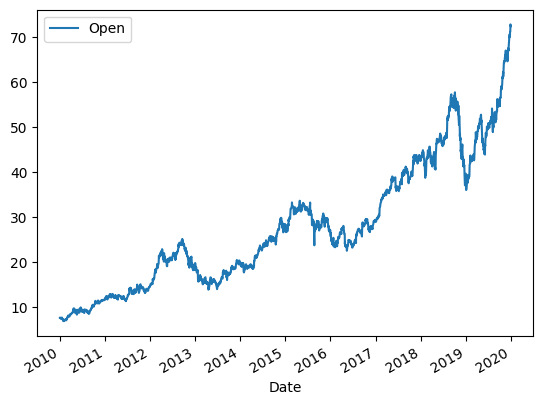

In [7]:
opn.plot()

In [8]:
ds = opn.values

In [9]:
ds

array([[ 7.62249994],
       [ 7.66428614],
       [ 7.65642881],
       ...,
       [71.20500183],
       [72.77999878],
       [72.36499786]])

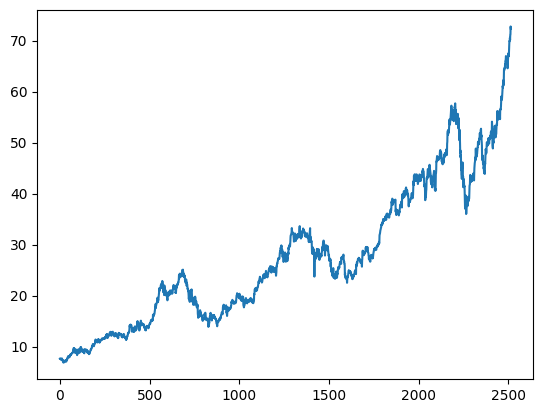

In [10]:
plt.plot(ds)

In [11]:
import numpy as np

In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
#Using MinMaxScaler for normalizing data between 0 & 1
normalizer = MinMaxScaler(feature_range=(0,1))
ds_scaled = normalizer.fit_transform(np.array(ds).reshape(-1,1))

In [14]:
len(ds_scaled), len(ds)

(2515, 2515)

In [15]:
#Defining test and train data sizes
train_size = int(len(ds_scaled)*0.70)
test_size = len(ds_scaled) - train_size

In [16]:
train_size,test_size

(1760, 755)

In [17]:
#Splitting data between train and test
ds_train, ds_test = ds_scaled[0:train_size,:], ds_scaled[train_size:len(ds_scaled),:1]

In [18]:
len(ds_train),len(ds_test)

(1760, 755)

In [19]:
#creating dataset in time series for LSTM model 
#X[100,120,140,160,180] : Y[200]
def create_ds(dataset,step):
    Xtrain, Ytrain = [], []
    for i in range(len(dataset)-step-1):
        a = dataset[i:(i+step), 0]
        Xtrain.append(a)
        Ytrain.append(dataset[i + step, 0])
    return np.array(Xtrain), np.array(Ytrain)

In [20]:
#Taking 100 days price as one record for training
time_stamp = 100
X_train, y_train = create_ds(ds_train,time_stamp)
X_test, y_test = create_ds(ds_test,time_stamp)

In [21]:
X_train.shape,y_train.shape

((1659, 100), (1659,))

In [22]:
X_test.shape, y_test.shape

((654, 100), (654,))

In [23]:
#Reshaping data to fit into LSTM model
X_train = X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

In [24]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [34]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Bidirectional

model = Sequential()
model.add(Bidirectional(LSTM(units=128, return_sequences=True, input_shape=(X_train.shape[1], 1))))
model.add(Bidirectional(LSTM(units=64)))
model.add(Dense(units=1))

In [35]:

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50
52/52 [==============================] - 18s 180ms/step - loss: 0.0031 - val_loss: 0.0023
Epoch 2/50
52/52 [==============================] - 9s 169ms/step - loss: 2.9782e-04 - val_loss: 0.0012
Epoch 3/50
52/52 [==============================] - 9s 172ms/step - loss: 1.4921e-04 - val_loss: 0.0011
Epoch 4/50
52/52 [==============================] - 8s 161ms/step - loss: 1.2103e-04 - val_loss: 5.7416e-04
Epoch 5/50
52/52 [==============================] - 8s 157ms/step - loss: 1.0964e-04 - val_loss: 6.6399e-04
Epoch 6/50
52/52 [==============================] - 9s 182ms/step - loss: 1.2738e-04 - val_loss: 4.5655e-04
Epoch 7/50
52/52 [==============================] - 9s 179ms/step - loss: 9.4497e-05 - val_loss: 4.5863e-04
Epoch 8/50
52/52 [==============================] - 10s 196ms/step - loss: 1.1006e-04 - val_loss: 7.7391e-04
Epoch 9/50
52/52 [==============================] - 11s 207ms/step - loss: 8.1783e-05 - val_loss: 0.0013
Epoch 10/50
52/52 [==========================

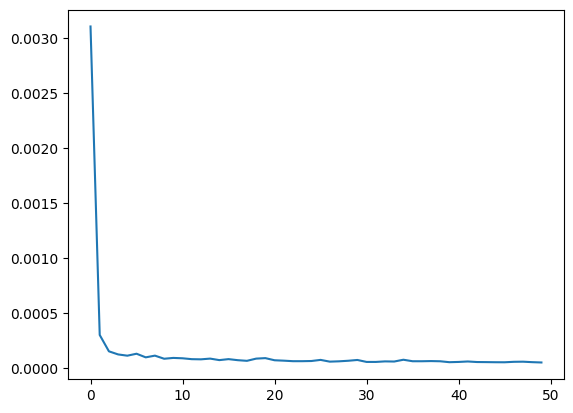

In [36]:
#PLotting loss, it shows that loss has decreased significantly and model trained well
loss = model.history.history['loss']
plt.plot(loss)

In [37]:
model.save("bi-lstm_model.h5")

In [28]:
#Predicitng on train and test data
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

21/21 [==============================] - 0s 20ms/step


In [29]:
type(train_predict)

numpy.ndarray

In [30]:
#Inverse transform to get actual value
train_predict = normalizer.inverse_transform(train_predict)
test_predict = normalizer.inverse_transform(test_predict)

In [31]:
type(ds_scaled)

numpy.ndarray

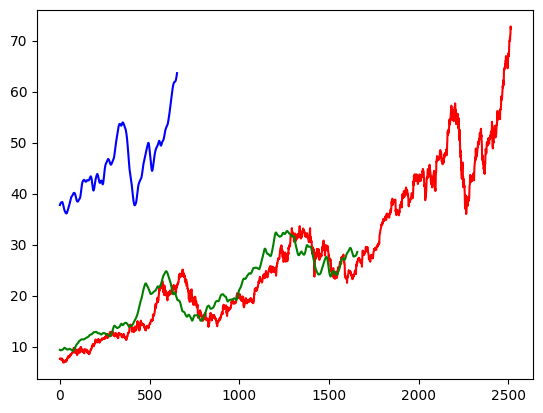

In [32]:
#Comparing using visuals
plt.plot(normalizer.inverse_transform(ds_scaled),'r')
plt.plot(train_predict,'g')
plt.plot(test_predict,'b')

In [33]:
type(train_predict)

numpy.ndarray

In [34]:
test = np.vstack((train_predict,test_predict))

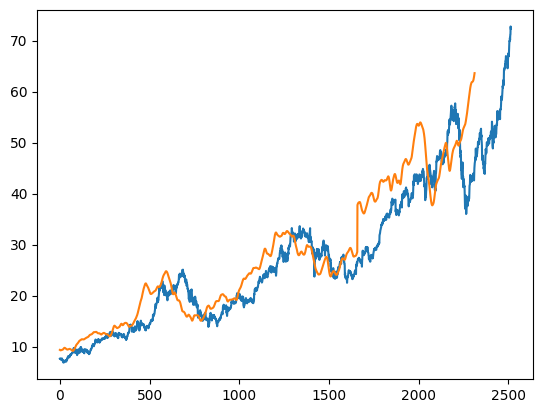

In [35]:
#Combining the predited data to create uniform data visualization
plt.plot(normalizer.inverse_transform(ds_scaled))
plt.plot(test)

In [36]:
len(ds_test)

755

In [37]:
#Getting the last 100 days records
fut_inp = ds_test[655:]

In [38]:
fut_inp = fut_inp.reshape(1,-1)

In [39]:
tmp_inp = list(fut_inp)

In [40]:
fut_inp.shape

(1, 100)

In [41]:
#Creating list of the last 100 data
tmp_inp = tmp_inp[0].tolist()

In [43]:
#Predicting next 30 days price suing the current data
#It will predict in sliding window manner (algorithm) with stride 1
lst_output=[]
n_steps=100
i=0
while(i<30):
    
    if(len(tmp_inp)>100):
        fut_inp = np.array(tmp_inp[1:])
        fut_inp=fut_inp.reshape(1,-1)
        fut_inp = fut_inp.reshape((1, n_steps, 1))
        yhat = model.predict(fut_inp, verbose=0)
        tmp_inp.extend(yhat[0].tolist())
        tmp_inp = tmp_inp[1:]
        lst_output.extend(yhat.tolist())
        i=i+1
    else:
        fut_inp = fut_inp.reshape((1, n_steps,1))
        yhat = model.predict(fut_inp, verbose=0)
        tmp_inp.extend(yhat[0].tolist())
        lst_output.extend(yhat.tolist())
        i=i+1
    

print(lst_output)

[[0.7399816513061523], [0.736090898513794], [0.732283353805542], [0.7285564541816711], [0.7249076962471008], [0.7213352918624878], [0.7178363800048828], [0.7144090533256531], [0.7110512852668762], [0.7077609300613403], [0.7045357823371887], [0.701374351978302], [0.6982743740081787], [0.6952343583106995], [0.6922521591186523], [0.689326822757721], [0.686456024646759], [0.6836384534835815], [0.6808727383613586], [0.6781575083732605], [0.6754909753799438], [0.672872006893158], [0.6702995300292969], [0.6677719354629517], [0.6652881503105164], [0.6628472805023193], [0.6604477763175964], [0.6580890417098999], [0.6557694673538208], [0.6534883379936218]]


In [44]:
type(lst_output)

list

In [45]:
len(ds_scaled)

2515

In [46]:
#Creating a dummy plane to plot graph one after another
plot_new=np.arange(1,101)
plot_pred=np.arange(101,131)

In [47]:
lst_output

[[0.7399816513061523],
 [0.736090898513794],
 [0.732283353805542],
 [0.7285564541816711],
 [0.7249076962471008],
 [0.7213352918624878],
 [0.7178363800048828],
 [0.7144090533256531],
 [0.7110512852668762],
 [0.7077609300613403],
 [0.7045357823371887],
 [0.701374351978302],
 [0.6982743740081787],
 [0.6952343583106995],
 [0.6922521591186523],
 [0.689326822757721],
 [0.686456024646759],
 [0.6836384534835815],
 [0.6808727383613586],
 [0.6781575083732605],
 [0.6754909753799438],
 [0.672872006893158],
 [0.6702995300292969],
 [0.6677719354629517],
 [0.6652881503105164],
 [0.6628472805023193],
 [0.6604477763175964],
 [0.6580890417098999],
 [0.6557694673538208],
 [0.6534883379936218]]

In [48]:
type(normalizer.inverse_transform(lst_output))

numpy.ndarray

In [49]:
normalizer.inverse_transform(lst_output)

array([[55.64228257],
       [55.38584445],
       [55.13489054],
       [54.88925192],
       [54.64876359],
       [54.4133077 ],
       [54.18269567],
       [53.9568018 ],
       [53.73549251],
       [53.51862638],
       [53.30605805],
       [53.0976893 ],
       [52.89337087],
       [52.69300452],
       [52.49644884],
       [52.30364097],
       [52.11442769],
       [51.92872259],
       [51.74643529],
       [51.56747546],
       [51.39172522],
       [51.21910995],
       [51.04955892],
       [50.88296607],
       [50.71926068],
       [50.55838382],
       [50.40023336],
       [50.24477001],
       [50.0918877 ],
       [49.94153928]])

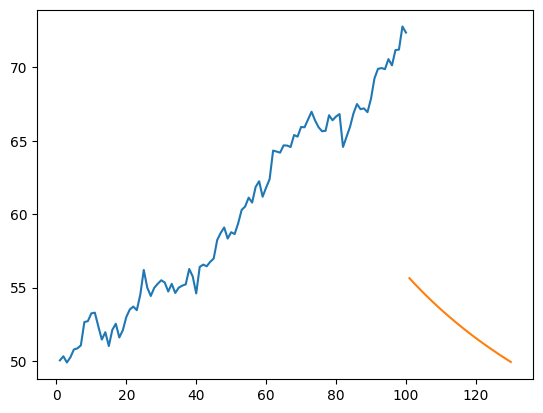

In [50]:
plt.plot(plot_new, normalizer.inverse_transform(ds_scaled[2415:]))
plt.plot(plot_pred, normalizer.inverse_transform(lst_output))

In [52]:
type(ds_scaled)

numpy.ndarray

In [51]:
ds_new = ds_scaled.tolist()

In [61]:
len(ds_new)

2515

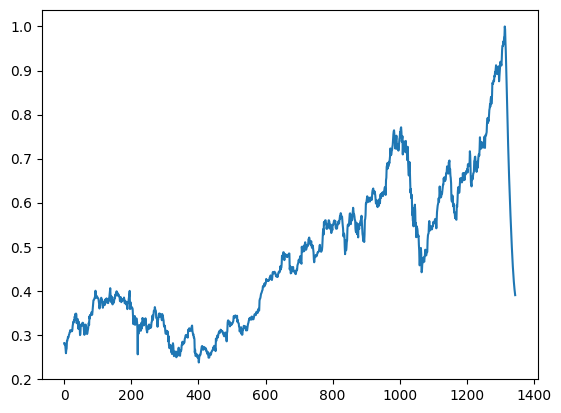

In [62]:
#Entends helps us to fill the missing value with approx value
ds_new.extend(lst_output)
plt.plot(ds_new[1200:])

In [63]:
#Creating final data for plotting
final_graph = normalizer.inverse_transform(ds_new).tolist()

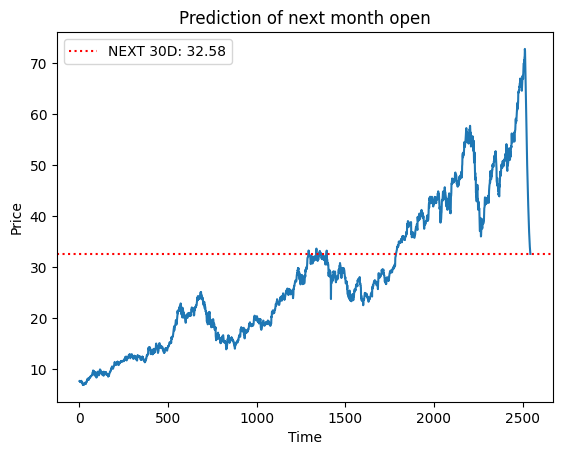

In [64]:
#Plotting final results with predicted value after 30 Days
plt.plot(final_graph,)
plt.ylabel("Price")
plt.xlabel("Time")
plt.title("Prediction of next month open")
plt.axhline(y=final_graph[len(final_graph)-1], color = 'red', linestyle = ':', label = 'NEXT 30D: {0}'.format(round(float(*final_graph[len(final_graph)-1]),2)))
plt.legend()